In [146]:
import yfinance as yf

import pandas as pd
import numpy as np
from scipy.stats import skew, norm
from statsmodels.tsa.stattools import adfuller

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import os

In [129]:
def download_raw(start_date="2019-01-01", end_date="2024-01-01", file_path="data/raw/raw_data.csv"):
    # Full list of S&P 100 Tickers
    tickers = [
        "AAPL", "ABBV", "ABT"  , "ACN" , "ADBE", "AMAT", "AMD", "AMGN", "AMT"  , "AMZN",
        "AVGO", "AXP" , "BA"   , "BAC" , "BK"  , "BKNG", "BLK", "BMY" , "BRK-B", "C"   ,
        "CAT" , "CL"  , "CMCSA", "COF" , "COP" , "COST", "CRM", "CSCO", "CVS"  , "CVX" ,
        "DE"  , "DHR" , "DIS"  , "DUK" , "EMR" , "FDX" , "GD" , "GE"  , "GILD" , "GEV" ,
        "GM"  , "GOOG", "GOOGL", "GS"  , "HD"  , "HON" , "IBM", "INTC", "INTU" , "ISRG",
        "JNJ" , "JPM" , "KO"   , "LIN" , "LLY" , "LMT" , "LOW", "LRCX", "MA"   , "MCD" ,
        "MDLZ", "MDT" , "META" , "MMM" , "MO"  , "MRK" , "MS" , "MSFT", "MU"   , "NEE" ,
        "NFLX", "NKE" , "NOW"  , "NVDA", "ORCL", "PEP" , "PFE", "PG"  , "PLTR" , "PM"  ,
        "QCOM", "RTX" , "SBUX" , "SCHW", "SO"  , "SPG" , "T"  , "TMO" , "TMUS" , "TSLA",
        "TXN" , "UBER", "UNH"  , "UNP" , "UPS" , "USB" , "V"  , "VZ"  , "WFC"  , "WMT" , 
        "XOM" ,
    ]
    
    print(f"Downloading data for {len(tickers)} tickers...")
    
    # auto_adjust=True ensures the 'Close' prices are fully adjusted for splits and dividends.
    raw = yf.download(
        tickers,
        start=start_date,
        end=end_date,
        auto_adjust=True,
        progress=False,
        group_by="column"
        )

    if raw.empty:
        raise ValueError("Downloaded data is empty.")
    
    # Save locally to avoid re-downloading
    raw.to_csv(file_path)
    
    print(f"Data saved to {file_path}")
    #print(raw.head())
    return raw

def load_raw(file_path="data/raw/raw_data.csv"):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Cannot find {file_path}. Ensure it is in your project directory.")
        
    print(f"Loading local data from {file_path}...")
    
    # Load the data, setting the first column (Date) as the index
    # parse_dates=True ensures the index is treated as time-series data
    raw = pd.read_csv(file_path, index_col=0) #, parse_dates=True)
    
    print(f"Original data shape: {raw.shape}")
    
    print("Raw data loading complete.")
    return raw

def get_prices_returns_volume(raw, prices_file_path="data/raw/prices.csv", returns_file_path="data/raw/returns.csv", volume_file_path="data/raw/volume.csv", save=True):

    num_tickers = raw.shape[1]
    tickers = raw.iloc[0,:num_tickers].copy()

    # keep only actual data rows
    prices = raw.iloc[2:,0:num_tickers].copy()
    volume = raw.iloc[2:,-num_tickers:0].copy()
    
    # assign ticker names as columns
    prices.columns = tickers
    volume.columns = tickers
    
    # name the index
    prices.index = pd.to_datetime(prices.index, errors="coerce")
    volume.index = pd.to_datetime(volume.index, errors="coerce")
    
    prices.index.name = "date"
    volume.index.name = "date"
    
    # convert values to numeric
    prices = prices.apply(pd.to_numeric, errors="coerce")
    volume = volume.apply(pd.to_numeric, errors="coerce")

    # Calculate daily log returns: ln(P_t / P_{t-1})
    # This transforms absolute prices into a normalized rate of change
    prices = prices.copy()
    prices = prices.apply(pd.to_numeric, errors="coerce")
    prices = prices.replace([np.inf, -np.inf], np.nan)
    #prices = prices.where(prices > 0)

    log_prices = np.log(prices)
    returns = log_prices.diff()
    returns = returns.iloc[1:]
    print(f"Returns calculated. Shape: {returns.shape}")
    
    if save:
        
        prices.to_csv(prices_file_path)
        print(f"Price data saved to {prices_file_path}")

        returns.to_csv(returns_file_path)
        print(f"Returns data saved to {returns_file_path}")
    
        volume.to_csv(volume_file_path)
        print(f"Volume data saved to {volume_file_path}")
    
    return prices, returns, volume

def get_prices_long(prices_wide, file_path="data/raw/prices_long.csv", save=True):
    prices_wide = prices_wide.sort_index()
    prices_wide.index.name = "date"
    
    prices_long = (
        prices_wide
        .reset_index()
        .melt(id_vars="date", var_name="ticker", value_name="adj_close")
    )
    
    prices_long["adj_close"] = pd.to_numeric(prices_long["adj_close"], errors="coerce")

    if save:
        prices_long.to_csv(file_path)
        print(f"Prices data saved to {file_path} in long-format")
    #print(prices_long.head())
    return prices_long

def get_returns_long(returns_wide, file_path="data/raw/returns_long.csv", save=True):
    returns_wide = returns_wide.sort_index()
    returns_wide.index.name = "date"

    returns_long = (
        returns_wide
        .reset_index()
        .melt(id_vars="date", var_name="ticker", value_name="return")
    )

    if save:
        returns_long.to_csv(file_path)
        print(f"Returns data saved to {file_path} in long-format")
        
    #print(returns_long.head())
    return returns_long


def get_volume_long(volume_wide, file_path="data/raw/volume_long.csv", save=True):
    volume_wide = volume_wide.sort_index()
    volume_wide.index.name = "date"
    
    volume_long = (
        volume_wide
        .reset_index()
        .melt(id_vars="date", var_name="ticker", value_name="volume")
    )
    
    volume_long["volume"] = pd.to_numeric(volume_long["volume"], errors="coerce")

    if save:
        volume_long.to_csv(file_path)
        print(f"Volume data saved to {file_path} in long-format")
    #print(volume_long.head())
    return volume_long



In [132]:
def get_metadata(df, file_path="data/raw/universe_metadata.csv", save=True):

    def longest_missing_streak(mask):
        # mask = True where missing
        max_streak = current = 0
        for x in mask:
            if x:
                current += 1
                max_streak = max(max_streak, current)
            else:
                current = 0
        return max_streak
    
    dates = df.index
    expected_days = len(dates)
    
    report = []
    for ticker in df.columns:
        c = df[ticker]
        non_na = c.notna().sum()
        missing_mask = c.isna().to_numpy()
        mu = c.mean()
        sigma = c.std()
        outliers = (np.abs(c) > 5 * sigma).sum()
    
        try:
            info = yf.Ticker(ticker).info
            report.append({
                "ticker": ticker,
                "company_name": info.get("shortName"),
                "sector": info.get("sector"),
                "industry": info.get("industry"),
                "market_cap": info.get("marketCap"),
                "country": info.get("country"),
                "exchange": info.get("exchange"),
                "return_non_na": non_na,
                "return_coverage": non_na / expected_days,
                "first_valid_date": c.first_valid_index(),
                "last_valid_date": c.last_valid_index(),
                "missing_days": expected_days - non_na,
                "longest_missing_streak": longest_missing_streak(missing_mask),
                "return_mean": mu,
                "return_std": sigma,
                "outlier_count_5sigma": outliers,
                "annualized_vol": c.std() * np.sqrt(252),
            })
        except Exception:
            report.append({
                "ticker": ticker,
                "company_name": None,
                "sector": None,
                "industry": None,
                "market_cap": None,
                "country": None,
                "exchange": None,
                "return_non_na": non_na,
                "return_coverage": non_na / expected_days,
                "first_valid_date": c.first_valid_index(),
                "last_valid_date": c.last_valid_index(),
                "missing_days": expected_days - non_na,
                "longest_missing_streak": longest_missing_streak(missing_mask),
                "return_mean": mu,
                "return_std": sigma,
                "outlier_count_5sigma": outliers,
                "annualized_vol": c.std() * np.sqrt(252),
            })
    
    metadata = pd.DataFrame(report).sort_values("return_coverage", ascending=False)
    if save:
        metadata.to_csv(file_path, index=False)
        print(f"Metadata saved to {file_path}")
    return metadata

def load_metadata(file_path="data/raw/universe_metadata.csv"):
    metadata = pd.read_csv(file_path)
    return metadata

In [131]:
raw = load_raw()

prices, returns, volume = get_prices_returns_volume(raw)

returns_long = get_returns_long(returns)
volume_long = get_volume_long(volume)

panel = returns_long.merge(volume_long, on=["date", "ticker"], how="left")

metadata = load_metadata(returns)

Loading local data from data/raw_data.csv...
Original data shape: (1260, 500)
Raw data loading complete.
Returns calculated. Shape: (1257, 100)
Price data saved to data/prices.csv
Returns data saved to data/returns.csv
Volume data saved to data/volume.csv
Metadata saved to data/universe_metadata.csv


In [145]:
def process_universe_etfs(metadata_path="data/raw/universe_metadata.csv"):
    if not os.path.exists(metadata_path):
        raise FileNotFoundError(f"Cannot find {metadata_path}. Please run the metadata generation first.")
        
    print(f"Loading metadata from {metadata_path}...")
    metadata = pd.read_csv(metadata_path)

    # 1. Define the strictly 1-to-1 SPDR ETF mapping
    sector_to_etf = {
        "Technology": "XLK",
        "Financial Services": "XLF",
        "Healthcare": "XLV",
        "Consumer Cyclical": "XLY",
        "Industrials": "XLI",
        "Communication Services": "XLC",
        "Consumer Defensive": "XLP",
        "Energy": "XLE",
        "Utilities": "XLU",
        "Real Estate": "XLRE",
        "Basic Materials": "XLB"
    }

    # 2. Map the sector column to the new ETF column
    metadata['etf'] = metadata['sector'].map(sector_to_etf)

    # 3. Save the updated metadata back to the CSV
    metadata.to_csv(metadata_path, index=False)
    print(f"Successfully added 'etf' column and updated {metadata_path}")
    
    # 4. Extract the unique, non-null ETFs needed for downloading
    unique_etfs = metadata['etf'].dropna().unique().tolist()
    print(f"Identified {len(unique_etfs)} unique sector ETFs: {unique_etfs}")

    # 5. Build Dictionaries
    ticker_to_etfs = {}
    # Initialize etf_to_tickers with empty lists for all possible mapped ETFs
    etf_to_tickers = {etf: [] for etf in sector_to_etf.values()}

    for _, row in metadata.iterrows():
        ticker = row['ticker']
        etf = row['etf']
        
        if pd.notna(etf):
            # Maintaining the list format [etf] for the ticker mapping
            ticker_to_etfs[ticker] = [etf]
            etf_to_tickers[etf].append(ticker)
        else:
            ticker_to_etfs[ticker] = []

    # Clean up empty ETF lists (in case a sector had no stocks in your universe)
    etf_to_tickers = {k: v for k, v in etf_to_tickers.items() if len(v) > 0}

    return metadata, unique_etfs, ticker_to_etfs, etf_to_tickers

def download_prices_etf(etfs, start_date="2019-01-01", end_date="2024-01-01", file_path="data/prices_etf.csv"):
    if not etfs:
        raise ValueError("ETF list is empty. Cannot download data.")
        
    print(f"\nDownloading data for {len(etfs)} ETFs...")
    
    # Download fully adjusted closing prices
    prices_etf = yf.download(
        etfs,
        start=start_date,
        end=end_date,
        auto_adjust=True,
        progress=False,
        group_by="column"
    )['Close']
    
    if prices_etf.empty:
        raise ValueError("Downloaded ETF data is empty.")

    # 1. Forward-fill any missing days (crucial for market indices to prevent NaN propagation)
    prices_etf = prices_etf.apply(pd.to_numeric, errors="coerce")
    prices_etf = prices_etf.replace([np.inf, -np.inf], np.nan)
    
    # 2. Convert to Long Format to match your stock price architecture
    prices_etf.index.name = "date"

    prices_etf.to_csv(file_path)
    print(f"ETF prices data saved to {file_path}")
    return prices_etf

def load_prices_etf(file_path="data/raw/prices_etf.csv"):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Cannot find {file_path}. Ensure it is in your project directory.")
        
    print(f"Loading local data from {file_path}...")
    
    # Load the data, setting the first column (Date) as the index
    # parse_dates=True ensures the index is treated as time-series data
    prices_etf = pd.read_csv(file_path, index_col=0) #, parse_dates=True)
    
    print(f"Original data shape: {raw.shape}")
    
    print("Raw data loading complete.")
    return raw

def get_returns_etf(prices_etf, file_path="data/raw/returns_etf.csv", save=True):
    
    log_prices_etf = np.log(prices_etf)
    returns_etf = log_prices_etf.diff()
    returns_etf = returns_etf.iloc[1:]
    print(f"Returns calculated. Shape: {returns_etf.shape}")
    
    if save:
        returns_etf.to_csv(file_path)
        print(f"ETF returns data saved to {file_path}")
    
    return returns_etf

def get_returns_long_etf(returns_etf, file_path="data/raw/returns_long_etf.csv", save=True):
    returns_long_etf = (
        returns_etf
        .reset_index()
        .melt(id_vars="date", var_name="ticker", value_name="adj_close")
    )
    
    # Ensure standard numeric typing
    returns_long_etf["adj_close"] = pd.to_numeric(returns_long_etf["adj_close"], errors="coerce")
    
    # 3. Save locally
    if save:
        returns_long_etf.to_csv(file_path, index=False)
        print(f"ETF returns data saved to {file_path} in long-format")
    
    return returns_long_etf



Loading metadata from data/universe_metadata.csv...
Successfully added 'etf' column and updated data/universe_metadata.csv
Identified 11 unique sector ETFs: ['XLK', 'XLY', 'XLC', 'XLU', 'XLF', 'XLV', 'XLP', 'XLI', 'XLB', 'XLRE', 'XLE']

ETF prices data saved to data/prices_etf.csv
Returns calculated. Shape: (1257, 11)
ETF returns data saved to data/returns_etf.csv


In [ ]:
# Single execution call
metadata, etfs, t2e, e2t = process_universe_etfs()

prices_etf = download_prices_etf(etfs)
returns_etf = get_returns_etf(prices_etf)
returns_long_etf = get_returns_long_etf(returns_etf, save=False)

In [153]:
def plot_sector_correlation(returns_wide, metadata, save_path="data/results/sector_correlation_heatmap.png"):
    print("Filtering universe for full coverage and sorting by sector...")
    
    # 1. Filter for full coverage (no missing data)
    valid_meta = metadata[metadata['return_coverage'] == 1.0].copy()
    
    # 2. Sort by Sector (ETF) first, then by Ticker (for alphabetical neatness within sectors)
    # Dropping any that might somehow lack an ETF mapping
    valid_meta = valid_meta.dropna(subset=['etf'])
    valid_meta = valid_meta.sort_values(by=['etf', 'ticker'])
    
    # 3. Extract the ordered lists
    ordered_tickers = valid_meta['ticker'].tolist()
    ordered_etfs = valid_meta['etf'].tolist()
    
    print(f"Kept {len(ordered_tickers)} highly liquid, full-coverage stocks.")
    
    # 4. Filter the returns dataframe using the ordered list
    # This automatically aligns the columns of the correlation matrix by sector
    clean_returns = returns_wide[ordered_tickers]
    
    # 5. Compute the empirical correlation matrix
    print("Computing correlation matrix...")
    corr_matrix = clean_returns.corr()
    
    # 6. Find the index boundaries where the sector changes
    # This is used to draw the black boxes around the sector blocks
    boundaries = []
    sector_labels = []
    current_etf = ordered_etfs[0]
    
    for i, etf in enumerate(ordered_etfs):
        if etf != current_etf:
            boundaries.append(i)
            sector_labels.append((current_etf, i)) # Store where the sector ends
            current_etf = etf
    sector_labels.append((current_etf, len(ordered_etfs)))
    
    # 7. Visualization
    print("Generating heatmap...")
    # Adjust figsize depending on how many stocks you have (12x10 is good for ~100)
    plt.figure(figsize=(14, 12))
    
    # Create the heatmap. 
    # cmap='coolwarm' maps negative corr to blue, 0 to white, positive to red
    ax = sns.heatmap(corr_matrix, cmap='coolwarm', vmin=0.0, vmax=1.0, 
                     xticklabels=False, yticklabels=False, cbar_kws={'shrink': 0.8})
                     
    # Draw boundary lines to explicitly show the sector blocks
    for b in boundaries:
        ax.axhline(b, color='black', linewidth=1.5)
        ax.axvline(b, color='black', linewidth=1.5)
        
    # Add an outer border
    ax.axhline(0, color='black', linewidth=3)
    ax.axhline(len(ordered_tickers), color='black', linewidth=3)
    ax.axvline(0, color='black', linewidth=3)
    ax.axvline(len(ordered_tickers), color='black', linewidth=3)

    plt.title('S&P 100 Empirical Correlation Matrix (Clustered by Sector)', fontsize=16, pad=20)
    plt.tight_layout()
    
    # Save and display
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Heatmap saved to {save_path}")
    plt.show()
    
    return corr_matrix, ordered_tickers

Filtering universe for full coverage and sorting by sector...
Kept 98 highly liquid, full-coverage stocks.
Computing correlation matrix...
Generating heatmap...
Heatmap saved to data/sector_correlation_heatmap.png


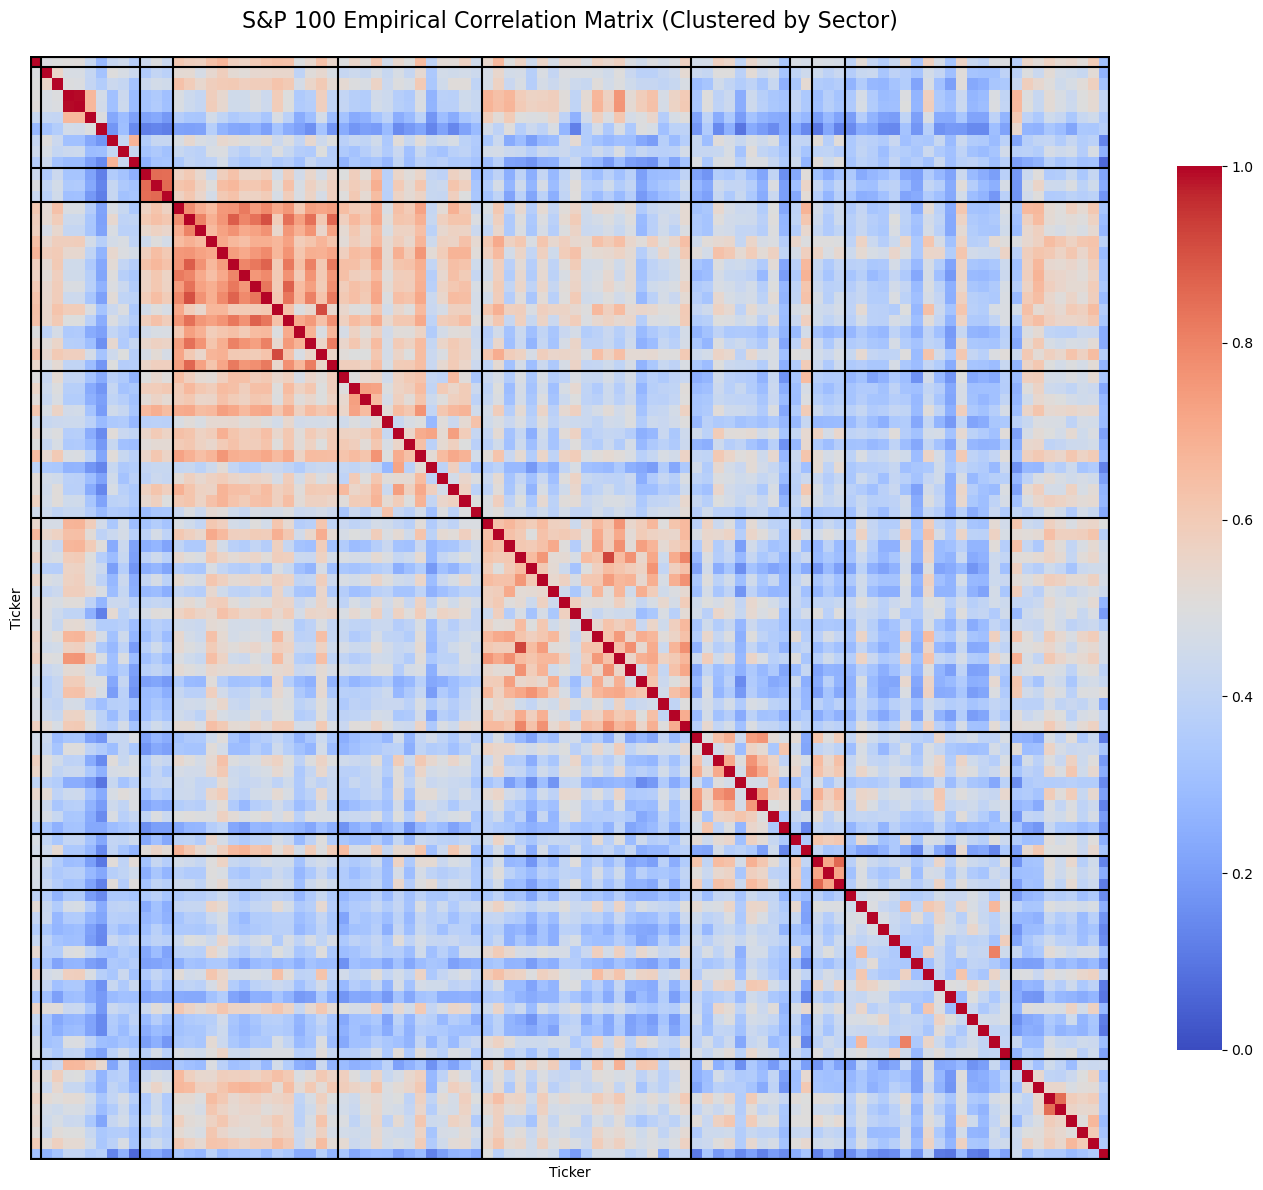

In [154]:
corr_matrix, ordered_tickers = plot_sector_correlation(returns, metadata)

0.4339785201098535 0.016010525726112692 0.2996837357618229


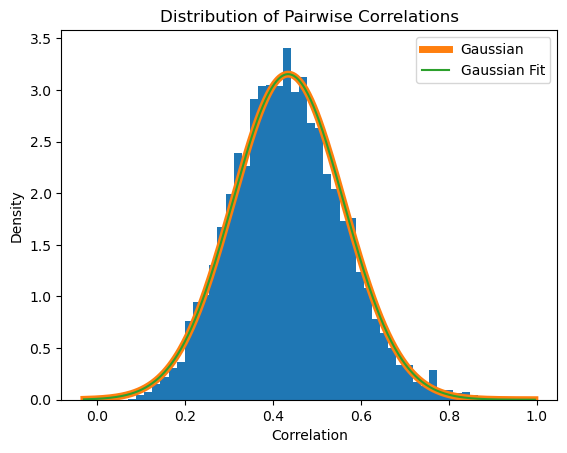

In [42]:
corr_dist = corr_mat.values[np.triu_indices(98, k=1)]

corr_mean = np.mean(corr_dist)
corr_var = np.var(corr_dist)
corr_skew = skew(corr_dist)

print(corr_mean, corr_var, corr_skew)

x = np.linspace(corr_dist.min()-0.1, corr_dist.max(), 500)
pdf_gauss = norm.pdf(x, corr_mean, np.sqrt(corr_var ))
#pdf_t = norm.pdf(x, corr_mean, np.sqrt(corr_sigma ))
#pdf_gauss = norm.pdf(x, corr_mean, np.sqrt(corr_sigma ))

mu, sigma = norm.fit(corr_dist)
pdf_gauss_fit = norm.pdf(x, mu, sigma)

plt.hist(corr_dist, bins=50, density=True)
plt.xlabel("Correlation")
plt.ylabel("Density")
plt.title("Distribution of Pairwise Correlations")

plt.plot(x, pdf_gauss, label="Gaussian", linewidth = 5)
plt.plot(x, pdf_gauss_fit, label="Gaussian Fit")
plt.legend()
#plt.plot(x, pdf_t, label="Student-t")
#plt.plot(x, pdf_skew, label="Skew-normal")

plt.show()

In [162]:
def get_rolling_universe(returns_wide, train_start, test_end):
    """
    Identifies stocks that have 100% data coverage across the entire 
    combined train and test window.
    """
    
    # Slice the dataframe to the exact combined window
    window_data = returns_wide.loc[train_start:test_end]
    
    # A stock is only valid if it has ZERO missing days in this specific window
    # .notna().all() checks if all rows in a column are non-null
    valid_mask = window_data.notna().all(axis=0)
    
    # Extract the ticker names that passed the mask
    valid_tickers = valid_mask[valid_mask].index.tolist()
    
    # Extract the cleanly sliced, full-coverage dataframe for these tickers
    clean_window_returns = window_data[valid_tickers]
    
    return valid_tickers, clean_window_returns

def compute_rolling_etf_baseline(clean_stock_returns, returns_etf_wide, t2e_dict, 
                                 train_start, train_end, test_start, test_end):
    """
    Computes out-of-sample residuals using a 1-factor OLS regression 
    against the stock's assigned sector ETF.
    """
    
    # 1. Slice the data into strict Train and Test windows
    train_stocks = clean_stock_returns.loc[train_start:train_end]
    test_stocks = clean_stock_returns.loc[test_start:test_end]
    
    train_etfs = returns_etf_wide.loc[train_start:train_end]
    test_etfs = returns_etf_wide.loc[test_start:test_end]
    
    # 2. Initialize a dataframe to hold the true out-of-sample residuals
    residuals_out_of_sample = pd.DataFrame(index=test_stocks.index, columns=test_stocks.columns)
    
    # Optional: Keep track of betas if you want to use them for hedging later
    betas_record = {} 
    
    for ticker in train_stocks.columns:
        # Get assigned ETF from your dictionary (default to SPY if mapping is missing)
        etf_list = t2e_dict.get(ticker, [])
        assigned_etf = etf_list[0] if len(etf_list) > 0 else "SPY"
        
        # --- TRAINING PHASE ---
        y_train = train_stocks[ticker].values
        x_train = train_etfs[assigned_etf].values
        
        # Add a column of 1s to the ETF data to calculate the intercept (alpha)
        X_train = np.vstack([np.ones(len(x_train)), x_train]).T
        
        # Run OLS using SVD-based least squares (extremely fast and stable)
        coeffs, _, _, _ = np.linalg.lstsq(X_train, y_train, rcond=None)
        alpha = coeffs[0]
        beta = coeffs[1]
        
        betas_record[ticker] = {assigned_etf: beta}
        
        # --- TESTING PHASE (Out-of-Sample) ---
        y_test = test_stocks[ticker].values
        x_test = test_etfs[assigned_etf].values
        
        # Predict the stock's macro return using the frozen Train parameters
        y_pred = alpha + (beta * x_test)
        
        # The idiosyncratic residual is the actual return minus the macro prediction
        residuals_out_of_sample[ticker] = y_test - y_pred
        
    return residuals_out_of_sample, betas_record

def run_master_backtest_loop(returns_wide, returns_etf_wide, t2e_dict, 
                             train_days=252, test_days=21):
    """
    Orchestrates the walk-forward rolling backtest.
    Rolls forward by 'test_days' until the end of the dataset is reached.
    """
    
    # Ensure indices are properly aligned and sorted
    returns_wide = returns_wide.sort_index()
    returns_etf_wide = returns_etf_wide.sort_index()
    
    total_trading_days = len(returns_wide)
    current_idx = 0
    
    all_oos_residuals = []
    
    print(f"Starting master rolling loop. Total trading days: {total_trading_days}")
    
    # Loop continues as long as we have enough data for a full Train + Test window
    while current_idx + train_days + test_days <= total_trading_days:
        
        # 1. Define integer boundaries for this specific step
        train_start_idx = current_idx
        train_end_idx = current_idx + train_days - 1
        test_start_idx = current_idx + train_days
        
        # We subtract 1 because .loc slicing in pandas is inclusive on both ends
        test_end_idx = current_idx + train_days + test_days - 1 
        
        # 2. Extract the actual datetime indices
        train_start = returns_wide.index[train_start_idx]
        train_end = returns_wide.index[train_end_idx]
        test_start = returns_wide.index[test_start_idx]
        test_end = returns_wide.index[test_end_idx]
        
        print(f"Rolling Step: Train [{train_start.date()} to {train_end.date()}] | "
              f"Test [{test_start.date()} to {test_end.date()}]")
        
        # 3. Create the clean universe for this specific window
        # (Assuming you have the get_rolling_universe function we wrote earlier)
        valid_tickers, clean_window_returns = get_rolling_universe(returns_wide, train_start, test_end)
        
        if len(valid_tickers) == 0:
            print("Warning: No valid tickers found for this window. Skipping.")
            current_idx += test_days
            continue
            
        # 4. Run the ETF Regression to get out-of-sample residuals
        # (Assuming you have the compute_rolling_etf_baseline function)
        residuals_oos, _ = compute_rolling_etf_baseline(
            clean_window_returns, returns_etf_wide, t2e_dict,
            train_start, train_end, test_start, test_end
        )
        
        # 5. Store the out-of-sample results
        all_oos_residuals.append(residuals_oos)
        
        # 6. Step the window forward by exactly 1 month (21 trading days)
        current_idx += test_days
        
    print("\nLoop complete. Stitching data together...")
    
    # 7. Concatenate all 1-month chunks into a single massive dataframe
    # pandas will automatically align the rows by Date and the columns by Ticker.
    # If a stock was valid in 2020 but not 2021, it will naturally have NaNs in 2021.
    master_oos_residuals = pd.concat(all_oos_residuals, axis=0)
    
    # Ensure chronologically sorted
    master_oos_residuals = master_oos_residuals.sort_index()
    
    print(f"Master Residuals Shape: {master_oos_residuals.shape}")
    return master_oos_residuals


In [164]:
# Example usage:
# Assuming 'returns' is your wide dataframe of stock returns

train_start_date = "2019-01-02"
test_end_date = "2020-01-31" # 1 year train + 1 month test

universe, clean_returns = get_rolling_universe(returns, train_start_date, test_end_date)

print(f"Total stocks valid for window {train_start_date} to {test_end_date}: {len(universe)}")
print(f"Shape of clean window data: {clean_returns.shape}")


# Example integration assuming you have your dataframes loaded:
residuals_oos, rolling_betas = compute_rolling_etf_baseline(
    clean_returns, returns_etf, t2e, 
    "2019-01-02", "2019-12-31", # 252 Day Train
    "2020-01-02", "2020-01-31"  # 21 Day Test
)

# Example integration:
master_residuals = run_master_backtest_loop(
    returns, returns_etf, t2e, 
    train_days=252, test_days=21
)

Total stocks valid for window 2019-01-02 to 2020-01-31: 98
Shape of clean window data: (272, 98)
Starting master rolling loop. Total trading days: 1257
Rolling Step: Train [2019-01-03 to 2020-01-02] | Test [2020-01-03 to 2020-02-03]
Rolling Step: Train [2019-02-04 to 2020-02-03] | Test [2020-02-04 to 2020-03-04]
Rolling Step: Train [2019-03-06 to 2020-03-04] | Test [2020-03-05 to 2020-04-02]
Rolling Step: Train [2019-04-04 to 2020-04-02] | Test [2020-04-03 to 2020-05-04]
Rolling Step: Train [2019-05-06 to 2020-05-04] | Test [2020-05-05 to 2020-06-03]
Rolling Step: Train [2019-06-05 to 2020-06-03] | Test [2020-06-04 to 2020-07-02]
Rolling Step: Train [2019-07-05 to 2020-07-02] | Test [2020-07-06 to 2020-08-03]
Rolling Step: Train [2019-08-05 to 2020-08-03] | Test [2020-08-04 to 2020-09-01]
Rolling Step: Train [2019-09-04 to 2020-09-01] | Test [2020-09-02 to 2020-10-01]
Rolling Step: Train [2019-10-03 to 2020-10-01] | Test [2020-10-02 to 2020-10-30]
Rolling Step: Train [2019-11-01 to 202

Starting rolling backtest simulation...
Simulation Complete.
Performance plot saved to data/etf_baseline_performance.png


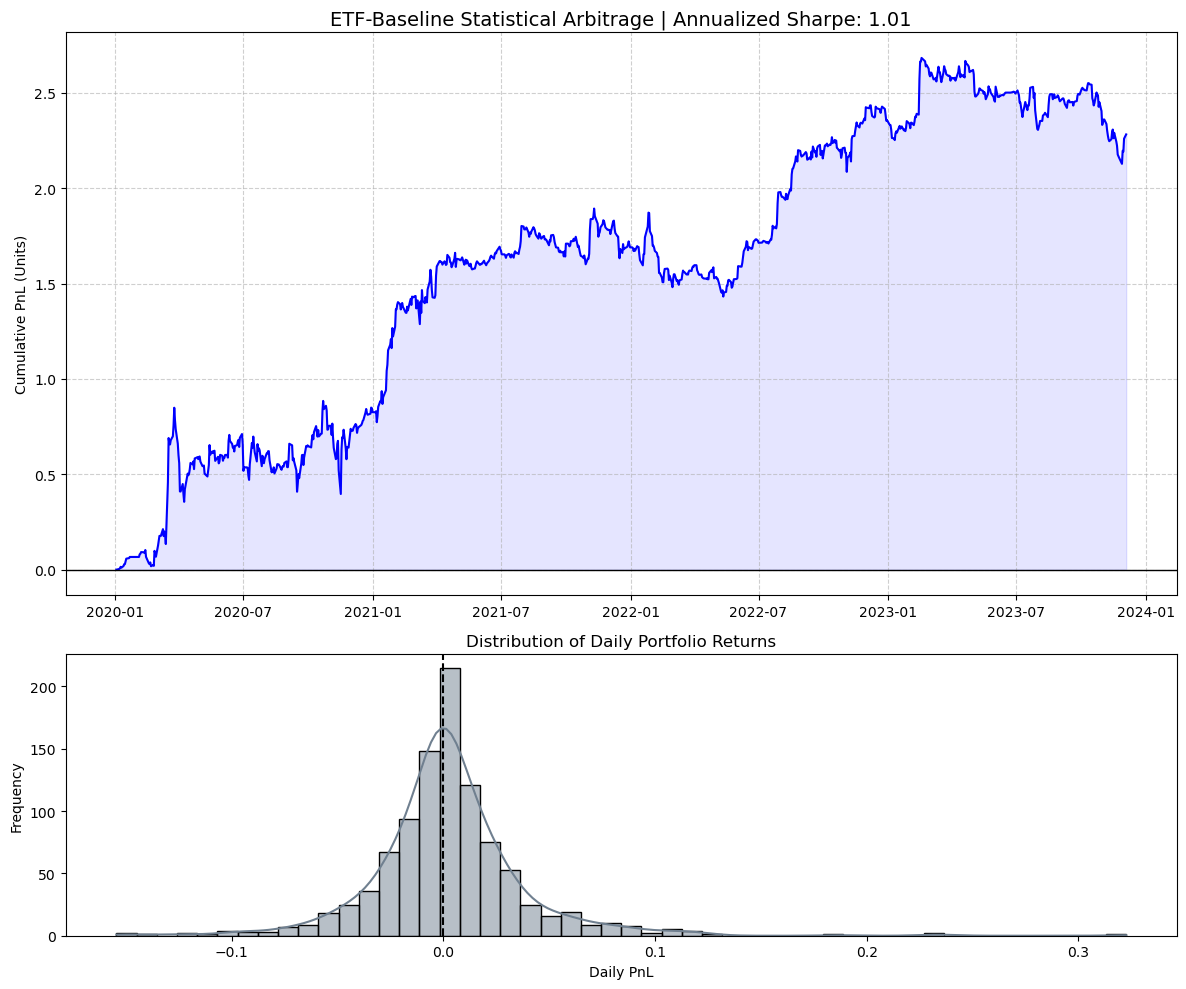

In [178]:
# ------------------------------------------------------------------------------
# 1. UNIVERSE FILTERING
# ------------------------------------------------------------------------------
def get_rolling_universe(returns_wide, train_start, test_end):
    """Identifies stocks with 100% data coverage across the rolling window."""
    window_data = returns_wide.loc[train_start:test_end]
    valid_mask = window_data.notna().all(axis=0)
    valid_tickers = valid_mask[valid_mask].index.tolist()
    clean_window_returns = window_data[valid_tickers]
    return valid_tickers, clean_window_returns

# ------------------------------------------------------------------------------
# 2. THE ETF REGRESSION BASELINE
# ------------------------------------------------------------------------------
def compute_rolling_split(clean_stock_returns, etf_returns, t2e_dict, 
                                       train_start, train_end, test_start, test_end):
    """
    Runs OLS against the assigned Sector ETF. 
    Returns BOTH the training residuals (for OU calibration) 
    and testing residuals (for out-of-sample trading), plus the betas.
    """
    train_stocks = clean_stock_returns.loc[train_start:train_end]
    test_stocks = clean_stock_returns.loc[test_start:test_end]
    train_etfs = etf_returns.loc[train_start:train_end]
    test_etfs = etf_returns.loc[test_start:test_end]
    
    residuals_train = pd.DataFrame(index=train_stocks.index, columns=train_stocks.columns)
    residuals_test = pd.DataFrame(index=test_stocks.index, columns=test_stocks.columns)
    betas_record = {} 
    
    for ticker in train_stocks.columns:
        etf_list = t2e_dict.get(ticker, [])
        assigned_etf = etf_list[0] if len(etf_list) > 0 else "SPY"
        
        # --- TRAIN ---
        y_train = train_stocks[ticker].values
        x_train = train_etfs[assigned_etf].values
        X_train = np.vstack([np.ones(len(x_train)), x_train]).T
        
        coeffs, _, _, _ = np.linalg.lstsq(X_train, y_train, rcond=None)
        alpha, beta = coeffs[0], coeffs[1]
        
        betas_record[ticker] = {assigned_etf: beta}
        residuals_train[ticker] = y_train - (alpha + beta * x_train)
        
        # --- TEST (Out of Sample) ---
        y_test = test_stocks[ticker].values
        x_test = test_etfs[assigned_etf].values
        residuals_test[ticker] = y_test - (alpha + beta * x_test)
        
    # Cast to float to prevent object-type errors downstream
    residuals_train = residuals_train.astype(float)
    residuals_test = residuals_test.astype(float)
    
    return residuals_train, residuals_test, betas_record

# ------------------------------------------------------------------------------
# 3. ORNSTEIN-UHLENBECK CALIBRATION
# ------------------------------------------------------------------------------
def calibrate_tradable_universe(train_residuals, adf_p_threshold=0.05):
    """Integrates residuals, runs ADF, and fits the OU process physics."""
    X_train = train_residuals.cumsum(axis=0)
    ou_parameters = {}
    
    for ticker in X_train.columns:
        path = X_train[ticker].values
        
        try:
            adf_stat, p_value, _, _, _, _ = adfuller(path, autolag='AIC')
        except Exception:
            continue 
            
        if p_value < adf_p_threshold:
            x_t = path[:-1]
            x_t_plus_1 = path[1:]
            
            A = np.vstack([np.ones(len(x_t)), x_t]).T
            coeffs, _, _, _ = np.linalg.lstsq(A, x_t_plus_1, rcond=None)
            a, b = coeffs
            
            if b <= 0 or b >= 1:
                continue
                
            epsilon = x_t_plus_1 - (a + b * x_t)
            var_epsilon = np.var(epsilon)
            
            m = a / (1 - b)
            sigma_eq = np.sqrt(var_epsilon / (1 - b**2))
            kappa = -np.log(b) * 252
            
            ou_parameters[ticker] = {
                'm': m,
                'sigma_eq': sigma_eq,
                'kappa': kappa,
                'X_train_end': path[-1] 
            }
    return ou_parameters

# ------------------------------------------------------------------------------
# 4. EXPLICITLY HEDGED TRADING SIMULATOR
# ------------------------------------------------------------------------------
def simulate_hedged_trading(test_stock_returns, test_etf_returns, test_residuals, 
                            ou_parameters, betas_record, t2e_dict, 
                            entry_threshold=1.25, exit_threshold=0.50):
    """Simulates market-neutral bang-bang trading on the test window."""
    pnl_df = pd.DataFrame(0.0, index=test_residuals.index, columns=list(ou_parameters.keys()))
    
    for ticker, params in ou_parameters.items():
        m = params['m']
        sigma_eq = params['sigma_eq']
        X_prev = params['X_train_end']
        
        etf_list = t2e_dict.get(ticker, [])
        assigned_etf = etf_list[0] if len(etf_list) > 0 else "SPY"
        beta = betas_record.get(ticker, {}).get(assigned_etf, 0.0)
        
        position = 0 
        
        for date, residual_return in test_residuals[ticker].items():
            stock_ret = test_stock_returns.at[date, ticker]
            etf_ret = test_etf_returns.at[date, assigned_etf]
            
            X_current = X_prev + residual_return
            s_score = (X_current - m) / sigma_eq
            
            if position == 1:
                pnl_df.at[date, ticker] = (1.0 * stock_ret) - (beta * etf_ret)
            elif position == -1:
                pnl_df.at[date, ticker] = (-1.0 * stock_ret) + (beta * etf_ret)
                
            if position == 0:
                if s_score < -entry_threshold:
                    position = 1  
                elif s_score > entry_threshold:
                    position = -1 
            elif position == 1:
                if s_score > -exit_threshold:
                    position = 0  
            elif position == -1:
                if s_score < exit_threshold:
                    position = 0  
                    
            X_prev = X_current
            
    portfolio_daily_pnl = pnl_df.sum(axis=1)
    return portfolio_daily_pnl
    



# ------------------------------------------------------------------------------
# 5. THE MASTER ORCHESTRATOR
# ------------------------------------------------------------------------------
def run_full_strategy(returns_wide, etf_returns, volume_wide, t2e_dict, train_days=252, test_days=21):
    """Steps the rolling window forward and aggregates out-of-sample portfolio returns."""
    returns_wide = returns_wide.sort_index()
    etf_returns = etf_returns.sort_index()
    total_trading_days = len(returns_wide)
    current_idx = 0
    
    all_portfolio_returns = []
    
    print("Starting rolling backtest simulation...")
    
    while current_idx + train_days + test_days <= total_trading_days:
        train_start_idx = current_idx
        train_end_idx = current_idx + train_days - 1
        test_start_idx = current_idx + train_days
        test_end_idx = current_idx + train_days + test_days - 1 
        
        train_start = returns_wide.index[train_start_idx]
        train_end = returns_wide.index[train_end_idx]
        test_start = returns_wide.index[test_start_idx]
        test_end = returns_wide.index[test_end_idx]

        valid_tickers, clean_window_returns = get_rolling_universe(returns_wide, train_start, test_end)

        if len(valid_tickers) > 0:
        
            # 1. Apply the Dampener FIRST
            adjusted_window_returns = apply_volume_dampener(
                clean_window_returns, volume_wide, 
                train_start, test_end
            )
            
            # 2. Pass the ADJUSTED returns to the ETF Regression
            residuals_train, residuals_test, betas = compute_rolling_split(
                adjusted_window_returns, etf_returns, t2e_dict, 
                train_start, train_end, test_start, test_end
            )
            
            ou_params = calibrate_tradable_universe(residuals_train)
            
            if len(ou_params) > 0:
                # We must pass the raw returns to the explicitly hedged simulator
                test_stock_returns = clean_window_returns.loc[test_start:test_end]
                
                daily_pnl = simulate_hedged_trading(
                    test_stock_returns, etf_returns, residuals_test, 
                    ou_params, betas, t2e_dict
                )
                all_portfolio_returns.append(daily_pnl)
            
        current_idx += test_days
        
    print("Simulation Complete.")
    
    strategy_returns = pd.concat(all_portfolio_returns, axis=0).sort_index()
    return strategy_returns

# ------------------------------------------------------------------------------
# 6. VISUALIZATION AND EXECUTION
# ------------------------------------------------------------------------------
def plot_performance(strategy_returns):
    """Plots the cumulative equity curve and daily returns distribution."""
    # Convert daily raw returns (summed across active pairs) to cumulative PnL
    cumulative_pnl = strategy_returns.cumsum()
    
    # Calculate Sharpe Ratio
    mean_daily_return = strategy_returns.mean()
    std_daily_return = strategy_returns.std()
    annualized_sharpe = np.sqrt(252) * (mean_daily_return / std_daily_return) if std_daily_return > 0 else 0
    
    # Set up matplotlib figure
    fig, axes = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [2, 1]})
    
    # Plot 1: Cumulative Equity Curve
    axes[0].plot(cumulative_pnl.index, cumulative_pnl.values, color='blue', linewidth=1.5)
    axes[0].fill_between(cumulative_pnl.index, cumulative_pnl.values, 0, color='blue', alpha=0.1)
    axes[0].axhline(0, color='black', linewidth=1)
    axes[0].set_title(f'ETF-Baseline Statistical Arbitrage | Annualized Sharpe: {annualized_sharpe:.2f}', fontsize=14)
    axes[0].set_ylabel('Cumulative PnL (Units)')
    axes[0].grid(True, linestyle='--', alpha=0.6)
    
    # Plot 2: Daily Returns Distribution
    sns.histplot(strategy_returns.values, bins=50, ax=axes[1], color='slategray', kde=True)
    axes[1].axvline(0, color='black', linestyle='--')
    axes[1].set_title('Distribution of Daily Portfolio Returns', fontsize=12)
    axes[1].set_xlabel('Daily PnL')
    axes[1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.savefig("data/etf_baseline_performance.png", dpi=300)
    print("Performance plot saved to data/etf_baseline_performance.png")
    plt.show()

if __name__ == "__main__":
    # Assuming 'returns', 'etf_long_data' (pivoted to wide), and 't2e' are in memory.
    # To run this, you need to pivot your etf_long data back to wide format:
    # etf_wide = etf_long_data.pivot(index='date', columns='ticker', values='adj_close').pct_change().dropna()
    
    strategy_daily_returns = run_full_strategy(returns, returns_etf, volume, t2e, train_days=252, test_days=21)
    plot_performance(strategy_daily_returns)
    pass

In [192]:
def compute_rolling_split_pca(clean_stock_returns, train_start, train_end, test_start, test_end, num_factors=15):
    """
    Extracts statistical factors via PCA on the correlation matrix of the training window.
    Regresses stocks against the top 'num_factors' eigenportfolios to generate residuals.
    """
    train_stocks = clean_stock_returns.loc[train_start:train_end]
    test_stocks = clean_stock_returns.loc[test_start:test_end]
    
    # ---------------------------------------------------------
    # STEP 1: PCA on the Correlation Matrix (Training Window)
    # ---------------------------------------------------------
    # Standardize training returns to force variance = 1
    train_mean = train_stocks.mean()
    train_std = train_stocks.std()
    Y_train = (train_stocks - train_mean) / train_std
    
    # Compute Correlation Matrix
    corr_matrix = Y_train.corr().values
    
    # Extract Eigenvalues and Eigenvectors
    # eigh is highly optimized for symmetric matrices like correlation matrices
    eigenvalues, eigenvectors = np.linalg.eigh(corr_matrix)
    
    # eigh returns them in ascending order. We need descending (largest variance first)
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # Keep only the top 'm' factors
    top_eigenvectors = eigenvectors[:, :num_factors]
    
    # ---------------------------------------------------------
    # STEP 2: Construct the Eigenportfolio Returns (F_j)
    # ---------------------------------------------------------
    # Avellaneda-Lee Eq 9: F_jk = Sum( v_i / sigma_i * R_ik )
    # This transforms abstract eigenvectors into physical portfolio returns
    
    # Shape of top_eigenvectors is (N_stocks, num_factors)
    # We divide each row by its stock's physical volatility (train_std)
    portfolio_weights = top_eigenvectors / train_std.values[:, np.newaxis]
    
    # Multiply the raw training returns (T x N) by the weights (N x m)
    # Resulting F_train is (T x m), the daily returns of our 15 hidden factors
    F_train = np.dot(train_stocks.values, portfolio_weights)
    
    # Do the same for the Test window (using the FROZEN training weights!)
    F_test = np.dot(test_stocks.values, portfolio_weights)
    
    # ---------------------------------------------------------
    # STEP 3: Multi-Factor Regression via SVD
    # ---------------------------------------------------------
    residuals_train = pd.DataFrame(index=train_stocks.index, columns=train_stocks.columns)
    residuals_test = pd.DataFrame(index=test_stocks.index, columns=test_stocks.columns)
    
    # Add a column of 1s for the intercept
    X_train_reg = np.hstack([np.ones((len(F_train), 1)), F_train])
    X_test_reg = np.hstack([np.ones((len(F_test), 1)), F_test])
    
    # We need to save the betas to calculate the explicit hedge PnL later
    # Format: betas_record[ticker] = array of 15 beta coefficients
    betas_record = {}
    
    for i, ticker in enumerate(train_stocks.columns):
        y_train = train_stocks[ticker].values
        
        # lstsq finds the alpha and 15 betas simultaneously
        coeffs, _, _, _ = np.linalg.lstsq(X_train_reg, y_train, rcond=None)
        
        # Calculate residuals
        # y - (X * coeffs)
        residuals_train[ticker] = y_train - np.dot(X_train_reg, coeffs)
        residuals_test[ticker] = test_stocks[ticker].values - np.dot(X_test_reg, coeffs)
        
        # Store the 15 betas (skipping coeffs[0] which is alpha)
        betas_record[ticker] = coeffs[1:]
        
    residuals_train = residuals_train.astype(float)
    residuals_test = residuals_test.astype(float)
    
    # We also return F_test so the simulator knows the returns of the hedging portfolios
    return residuals_train, residuals_test, betas_record, F_test, portfolio_weights

def simulate_hedged_trading_pca(test_stock_returns, test_residuals, 
                                ou_parameters, betas_record, F_test,
                                entry_threshold=1.25, exit_threshold=0.50):
    
    pnl_df = pd.DataFrame(0.0, index=test_residuals.index, columns=list(ou_parameters.keys()))
    
    for ticker, params in ou_parameters.items():
        m = params['m']
        sigma_eq = params['sigma_eq']
        X_prev = params['X_train_end']
        
        # Array of 15 beta loadings for this specific stock
        betas = betas_record[ticker]
        
        position = 0 
        
        # F_test contains the returns of the 15 factors for each day
        for day_idx, (date, residual_return) in enumerate(test_residuals[ticker].items()):
            stock_ret = test_stock_returns.at[date, ticker]
            
            # The return of our hedging basket is the sum of (Beta_j * F_j)
            hedge_ret = np.sum(betas * F_test[day_idx, :])
            
            X_current = X_prev + residual_return
            s_score = (X_current - m) / sigma_eq
            
            # Calculate Explicit Hedged PnL
            if position == 1:
                # Long Stock, Short the 15 Factors
                pnl_df.at[date, ticker] = stock_ret - hedge_ret
            elif position == -1:
                # Short Stock, Long the 15 Factors
                pnl_df.at[date, ticker] = -stock_ret + hedge_ret
                
            # Update Position State Machine
            if position == 0:
                if s_score < -entry_threshold:
                    position = 1  
                elif s_score > entry_threshold:
                    position = -1 
            elif position == 1:
                if s_score > -exit_threshold:
                    position = 0  
            elif position == -1:
                if s_score < exit_threshold:
                    position = 0  
                    
            X_prev = X_current
            
    portfolio_daily_pnl = pnl_df.sum(axis=1)
    return portfolio_daily_pnl

def run_full_strategy_pca(returns_wide, etf_returns, volume_wide, t2e_dict, train_days=252, test_days=21):
    """Steps the rolling window forward and aggregates out-of-sample portfolio returns."""
    returns_wide = returns_wide.sort_index()
    etf_returns = etf_returns.sort_index()
    total_trading_days = len(returns_wide)
    current_idx = 0
    
    all_portfolio_returns = []
    
    print("Starting rolling backtest simulation...")
    
    while current_idx + train_days + test_days <= total_trading_days:
        train_start_idx = current_idx
        train_end_idx = current_idx + train_days - 1
        test_start_idx = current_idx + train_days
        test_end_idx = current_idx + train_days + test_days - 1 
        
        train_start = returns_wide.index[train_start_idx]
        train_end = returns_wide.index[train_end_idx]
        test_start = returns_wide.index[test_start_idx]
        test_end = returns_wide.index[test_end_idx]
        
        valid_tickers, clean_window_returns = get_rolling_universe(returns_wide, train_start, test_end)
        
        # INSIDE THE MASTER WHILE LOOP:
        
        valid_tickers, clean_window_returns = get_rolling_universe(returns_wide, train_start, test_end)
        
        if len(valid_tickers) > 0:
            
            # --- NEW VOLUME ADJUSTMENT STEP ---
            # (Assuming you pivoted your volume_long data into volume_wide beforehand)
            adjusted_window_returns = apply_volume_dampener(
                clean_window_returns, volume_wide, 
                train_start, test_end
            )
            
            # Now, pass the ADJUSTED returns into your PCA engine instead of the raw returns
            residuals_train, residuals_test, betas, F_test, _ = compute_rolling_split_pca(
                adjusted_window_returns, # <--- Used here
                train_start, train_end, test_start, test_end, 
                num_factors=3
            )
            
            # The rest of the physics calibration and trading simulator remains exactly the same
            ou_params = calibrate_tradable_universe(residuals_train)
            
            if len(ou_params) > 0:
                # The simulator still uses the RAW stock returns to calculate actual dollar PnL
                test_stock_returns = clean_window_returns.loc[test_start:test_end]
                
                daily_pnl = simulate_hedged_trading_pca(
                    test_stock_returns, residuals_test, 
                    ou_params, betas, F_test
                )
                all_portfolio_returns.append(daily_pnl)
        
        current_idx += test_days
        
    print("Simulation Complete.")
    
    strategy_returns = pd.concat(all_portfolio_returns, axis=0).sort_index()
    return strategy_returns

Starting rolling backtest simulation...
Simulation Complete.
Performance plot saved to data/etf_baseline_performance.png


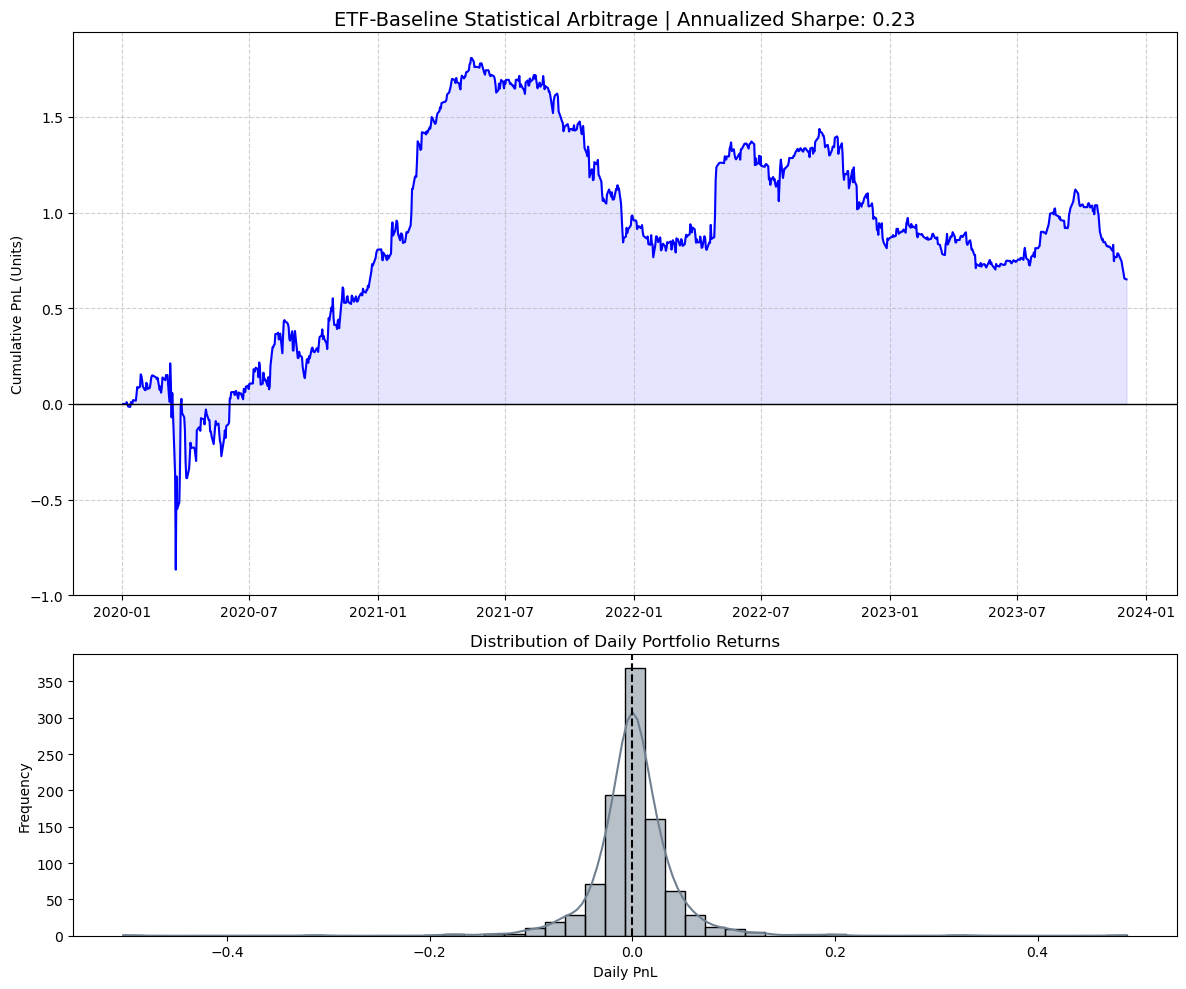

In [193]:
if __name__ == "__main__":
    # Assuming 'returns', 'etf_long_data' (pivoted to wide), and 't2e' are in memory.
    # To run this, you need to pivot your etf_long data back to wide format:
    # etf_wide = etf_long_data.pivot(index='date', columns='ticker', values='adj_close').pct_change().dropna()
    
    strategy_daily_returns_pca = run_full_strategy_pca(returns, returns_etf, volume, t2e, train_days=252, test_days=21)
    plot_performance(strategy_daily_returns_pca)